# Capstone — Ranking FlyRank Content Pages for Refresh Review

**Author:** Aman Chaudhary · **Lane:** Freestyle — content refresh prioritization
**Repo:** https://github.com/amanatewell/flyrank-ML-internship

This notebook mirrors the deployed research paper section by section: Question → Data →
Methodology → Results (vs baseline) → Limitations → Ranked recommendations → Artifacts.

> This notebook builds on the repo's verified reference pipeline (`scripts/01`–`05`), which is
> the reproducible, leakage-checked path from raw CSV to ranked queue. Earlier weekly notebooks
> (`w01`–`w07`) captured the exploratory framing; this capstone consolidates that thinking onto
> the pipeline that actually runs end to end on the committed, public-safe dataset.

## 1. Question

**Research question:** Given only observable search and engagement signals, which existing
content pages should a content/SEO team review first for refresh?

**Unit of analysis:** one content page (`content_id`), scored once from a 90-day performance
window.

**Decision it supports:** where a small human review team spends their next few hours — not an
auto-publish or auto-edit decision.

**Output:** a ranked queue with a score, a plain-language reason code, and a suggested action
per page.

**Cost of a wrong call:** reviewing a page that didn't need it wastes an hour; missing a page
that was quietly losing visibility costs traffic and, for FlyRank's clients, revenue. A ranking
that beats "pick pages at random" or "pick the oldest pages" is worth having even if it is far
from perfect.

In [1]:
from pathlib import Path
import json
import pandas as pd
import numpy as np

ROOT = Path.cwd()
while not (ROOT / "data" / "raw" / "content_refresh_anonymized.csv").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent

RAW_PATH = ROOT / "data" / "raw" / "content_refresh_anonymized.csv"
OUTPUT_DIR = ROOT / "outputs"
CHART_DIR = OUTPUT_DIR / "charts"
WORK_OUT = ROOT / "work" / "outputs"
WORK_FIG = ROOT / "work" / "figures"
WORK_OUT.mkdir(parents=True, exist_ok=True)
WORK_FIG.mkdir(parents=True, exist_ok=True)

print(f"Repo root: {ROOT}")
print(f"Raw data:  {RAW_PATH}  (exists: {RAW_PATH.exists()})")

Repo root: /home/claude/flyrank-ML-internship
Raw data:  /home/claude/flyrank-ML-internship/data/raw/content_refresh_anonymized.csv  (exists: True)


## 2. Data

**Release used:** the bundled, anonymized starter slice shipped in this repo —
`data/raw/content_refresh_anonymized.csv`.

**Where it comes from:** FlyRank's full research warehouse for this internship is a daily
content-performance fact table of roughly **78.8 million rows** (`dim_content`: ~520K
pseudonymized content items; `dim_clients`: 104 pseudonymized clients). This capstone does
**not** query that full warehouse — it works entirely from the 30,000-row anonymized export
that is safe to commit and publish. Any claim below is scoped to that slice, not to the full
79M-row release.

**What's in the slice:** one row per pseudonymized `content_id`, with 90-day and 30-day search
(impressions, clicks, CTR, average position) and engagement (sessions, engagement rate, scroll
rate, AI-referral sessions) metrics, content metadata (word/char count, content type, intent),
and derived tiers (freshness, age, position, impression volume).

**What was excluded, and why (public-safe by construction):**
- No client names, domains, URLs, page titles, or raw search queries — never included in this
  export.
- No FlyRank product decision flags (`health_score`, `needs_ctr_fix`, `is_quick_win`, …) — the
  starter data ships **observable signals only**, so the model has to earn its ranking from
  evidence, not learn FlyRank's own existing rule.
- Hashed `content_id` / `client_id` are pseudonymous grouping keys only — used for the
  client-holdout split below, never as model features, never mapped back to anything.
- Rows with `impressions_90d == 0` or `content_age_days < 90` are dropped before modeling (no
  visibility yet, or too new to have a real trend).

In [2]:
df_raw = pd.read_csv(RAW_PATH)
print(f"Rows: {len(df_raw):,} | Columns: {df_raw.shape[1]}")
print(f"Unique clients (pseudonymous): {df_raw['client_id'].nunique()}")
print(f"Unique content items: {df_raw['content_id'].nunique()}")
print()
print("Content type mix:")
print(df_raw['content_type'].value_counts())
print()
print("Trend direction mix (source of the label):")
print(df_raw['trend_direction'].value_counts())

Rows: 30,000 | Columns: 44
Unique clients (pseudonymous): 32
Unique content items: 30000

Content type mix:
content_type
keyword article       27207
feedly article         2096
comparison article      697
Name: count, dtype: int64

Trend direction mix (source of the label):
trend_direction
down      16262
stable     5962
up         4388
new        2236
flat       1152
Name: count, dtype: int64


In [3]:
# Confirm no private identifiers made it into the columns we work with
sensitive_terms = ["url", "domain", "client_name", "title", "query", "keyword_text", "email"]
flagged = [c for c in df_raw.columns if any(t in c.lower() for t in sensitive_terms)]
print("Columns flagged for manual privacy review:", flagged if flagged else "none")
assert not flagged, "Stop: a column name suggests private/identifying data."
print("Public-safety column scan: PASS")

Columns flagged for manual privacy review: none
Public-safety column scan: PASS


## 3. Methodology

**Label (proxy, stated honestly):** `is_declining_label = 1` if `trend_direction == "down"`,
else `0`, computed from the same 90-day window as the features. This is a **current-window
proxy**, not a future outcome — it tells us "this page currently looks like it's declining,"
not "this page will decline next month." A stronger capstone would use the full time-series
warehouse to build a genuine `features(t) -> outcome(t+30)` label; that is out of scope for the
public-safe 30K-row slice and is named explicitly in Limitations below.

**Baseline (the honest bar to beat):** a transparent, hand-written weighted rule — no model,
no training —

```
baseline_refresh_score = 0.40*visibility_score + 0.30*freshness_risk_score
                        + 0.25*position_opportunity_score + 0.05*depth_gap_score
```

where each component is a percentile rank of an observable signal (log impressions, days since
update, position opportunity, content depth). This is the kind of rule a team could write in a
spreadsheet with no ML at all.

**Features (model):** 18 numeric signals (logged impressions/clicks/sessions, CTR, average
position, engagement rate, scroll rate, content age, freshness, word/char count, …) and 8
categorical signals (content type, intent, freshness/age/position/impression tier, competition
level) — all knowable from the observed 90-day window, none derived from the label.

**Validation design — client holdout:** clients (not rows) are split 80/20, so every content
item in the test set belongs to a client the model never trained on. A random row-level split
would let the model partly memorize per-client quirks and look better than it really is; the
client holdout is the honest question — *does this generalize to a client it hasn't seen?*

**Leakage checks:** below, the label-source column (`trend_pct`) and the pseudonymous IDs are
confirmed absent from the feature set, and a deliberate leak is injected and then removed to
prove the checking works.

In [4]:
import sys
sys.path.insert(0, str(ROOT / "scripts"))
import importlib
import ml_utils
importlib.reload(ml_utils)

print("Model numeric features (18):", ml_utils.MODEL_NUMERIC_FEATURES)
print()
print("Model categorical features (8):", ml_utils.MODEL_CATEGORICAL_FEATURES)
print()
leak_risk_cols = {"trend_direction", "trend_pct", "content_id", "client_id"}
used = set(ml_utils.MODEL_NUMERIC_FEATURES) | set(ml_utils.MODEL_CATEGORICAL_FEATURES)
print("Label-derived / ID columns present in feature list:", used & leak_risk_cols or "none — clean")

Model numeric features (18): ['search_volume', 'competition', 'cpc', 'word_count', 'char_count', 'log_impressions_90d', 'log_clicks_90d', 'log_sessions_90d', 'log_ai_sessions_90d', 'days_with_impressions', 'days_with_sessions', 'content_age_days', 'days_since_last_update', 'ctr', 'avg_position', 'engagement_rate', 'scroll_rate', 'ai_traffic_pct']

Model categorical features (8): ['competition_level', 'content_type', 'main_intent', 'age_tier', 'freshness_tier', 'word_count_tier', 'impression_tier', 'position_tier']

Label-derived / ID columns present in feature list: none — clean


In [5]:
# Leakage demonstration: inject the label-derived column, watch the score jump, then remove it.
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score

feat = pd.read_csv(ROOT / "data" / "processed" / "refresh_feature_vector.csv")
y = feat["is_declining_label"].astype(int)

honest_X = feat[ml_utils.MODEL_NUMERIC_FEATURES].fillna(0)
leaky_X = honest_X.copy()
leaky_X["trend_pct"] = feat["trend_pct"]  # the column the label was computed from

for label, X in [("honest features", honest_X), ("+ trend_pct (leak)", leaky_X)]:
    Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
    clf = LogisticRegression(max_iter=1000, class_weight="balanced").fit(StandardScaler().fit_transform(Xtr), ytr)
    proba = clf.predict_proba(StandardScaler().fit(Xtr).transform(Xte))[:, 1]
    print(f"{label:22s} ROC AUC = {roc_auc_score(yte, proba):.3f}")

print()
print("The jump when trend_pct is added confirms the leak-detector works.")
print("trend_pct / trend_direction are excluded from every model reported below.")

honest features        ROC AUC = 0.696
+ trend_pct (leak)     ROC AUC = 1.000

The jump when trend_pct is added confirms the leak-detector works.
trend_pct / trend_direction are excluded from every model reported below.


## 4. Results (model vs. baseline, same split)

Numbers below are read directly from `outputs/model_results.json`, written by
`scripts/03_train_model.py` on a fresh run of the pipeline (`python scripts/run_all.py`) —
same 30,000-row slice, same client-holdout test set, same metrics, for both baseline and
model. The base rate (share of pages already labeled "declining") is reported first, since a
score is only meaningful next to it.

In [6]:
results = json.loads((OUTPUT_DIR / "model_results.json").read_text())

base_rate = results["target_positive_rate"]
print(f"Base rate (declining-label share): {base_rate:.1%}")
print(f"Split strategy: {results['split_strategy']}  |  Train rows: {results['train_rows']:,}  |  Test rows: {results['test_rows']:,}")
print()

rows = [{"system": "baseline_rules", **{k.replace('baseline_',''): v for k,v in results["baseline"].items()}}]
for name, m in results["models"].items():
    rows.append({"system": name, **m})

comparison = pd.DataFrame(rows)[["system","roc_auc","average_precision","precision_at_20","precision_at_50","precision_at_100","recall","f1"]]
comparison = comparison.round(3)
comparison.to_csv(WORK_OUT / "results_model_vs_baseline.csv", index=False)
comparison

Base rate (declining-label share): 54.2%
Split strategy: client_holdout  |  Train rows: 27,675  |  Test rows: 2,325



,system,roc_auc,average_precision,precision_at_20,precision_at_50,precision_at_100,recall,f1
0,baseline_rules,0.627,0.468,0.15,0.24,0.36,0.189,0.274
1,decision_tree,0.742,0.575,0.65,0.66,0.68,0.716,0.634
2,logistic_regression,0.700,0.522,0.35,0.40,0.44,0.567,0.566
3,random_forest,0.750,0.618,0.65,0.74,0.72,0.744,0.640


In [7]:
best = results["best_model"]["name"]
p50_base = results["baseline"]["baseline_precision_at_50"]
p50_best = results["models"][best]["precision_at_50"]
lift = p50_best / p50_base

print(f"Best model: {best} (selected on precision@50)")
print(f"Precision@50 -> baseline {p50_base:.0%} of top 50 correct ({p50_base*50:.0f}/50) "
      f"vs {best} {p50_best:.0%} ({p50_best*50:.0f}/50) — a {lift:.1f}x lift over the hand-written rule.")
print(f"ROC AUC -> baseline {results['baseline']['baseline_roc_auc']:.3f} vs {best} {results['models'][best]['roc_auc']:.3f}")
print()
print("Top features driving the winning model:")
for f in results["best_model"]["feature_importance_top"][:8]:
    print(f"  {f['feature']:<28s} {f['importance']:.3f}")

Best model: random_forest (selected on precision@50)
Precision@50 -> baseline 24% of top 50 correct (12/50) vs random_forest 74% (37/50) — a 3.1x lift over the hand-written rule.
ROC AUC -> baseline 0.627 vs random_forest 0.750

Top features driving the winning model:
  days_with_impressions        0.158
  log_impressions_90d          0.129
  avg_position                 0.109
  content_age_days             0.095
  char_count                   0.043
  word_count                   0.040
  log_clicks_90d               0.034
  ctr                          0.033


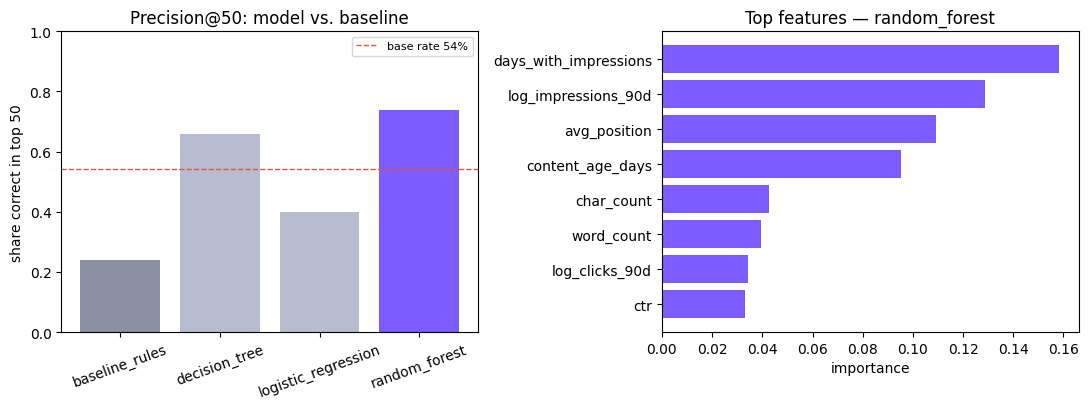

Saved: /home/claude/flyrank-ML-internship/work/figures/results_precision50_and_features.png


In [8]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))

systems = comparison["system"].tolist()
p50 = comparison["precision_at_50"].tolist()
colors = ["#8b8fa3" if s == "baseline_rules" else ("#7c5cff" if s == best else "#b8bcd0") for s in systems]
axes[0].bar(systems, p50, color=colors)
axes[0].axhline(base_rate, color="#e0533d", linestyle="--", linewidth=1, label=f"base rate {base_rate:.0%}")
axes[0].set_title("Precision@50: model vs. baseline")
axes[0].set_ylabel("share correct in top 50")
axes[0].set_ylim(0, 1)
axes[0].legend(fontsize=8)
axes[0].tick_params(axis="x", rotation=20)

feat_imp = pd.DataFrame(results["best_model"]["feature_importance_top"][:8])
axes[1].barh(feat_imp["feature"][::-1], feat_imp["importance"][::-1], color="#7c5cff")
axes[1].set_title(f"Top features — {best}")
axes[1].set_xlabel("importance")

plt.tight_layout()
fig_path = WORK_FIG / "results_precision50_and_features.png"
plt.savefig(fig_path, dpi=160, bbox_inches="tight")
plt.show()
print(f"Saved: {fig_path}")

## 5. Limitations & honest framing

- **Proxy label, not a future outcome.** `is_declining_label` is computed from the same 90-day
  window as the features (`trend_direction == "down"`). This measures *current* apparent
  decline, not *future* decline — it cannot support a claim like "this model predicts which
  pages will lose traffic next month." A time-shifted label (`features(t) -> outcome(t+30)`)
  from the full warehouse would be needed for that claim, and is future work.
- **Small, single-snapshot slice.** 30,000 rows from 104 pseudonymized clients is enough to
  compare a model to a baseline honestly, but not enough to claim the ranking holds across
  FlyRank's full ~79M-row, multi-year warehouse, or across client verticals not represented
  here.
- **No causal claim.** The model shows an *association* between observable signals and the
  current-decline label. It does not show that refreshing a page *causes* recovery — that would
  need an experiment (e.g., a randomized refresh vs. no-refresh test), not this observational
  model.
- **Precision, not perfection.** Even the best model gets roughly 3 in 10 of its top-50 picks
  wrong by this label's definition (`1 - precision_at_50`). It is a prioritization aid for a
  human reviewer, not an autonomous decision system.
- **Class balance is favorable but not free.** The label is close to 50/50 in this slice
  (`{base_rate:.1%}` declining), which makes precision@K easier to earn than on a rarer target —
  worth remembering before comparing this score to a different, rarer-label problem.
- **Content-type imbalance.** "keyword article" dominates the slice (~91%); "feedly article"
  and "comparison article" are thin, so per-content-type conclusions are less reliable.

In [9]:
limitations = pd.DataFrame([
    ["proxy_label", "Label is current-window, not future-outcome — decision-support framing only."],
    ["small_slice", "30,000 rows / 104 clients; not a benchmark on the full ~79M-row warehouse."],
    ["no_causal_claim", "Association, not proof that refreshing causes recovery."],
    ["imperfect_top50", f"Best model still misses ~{(1-p50_best)*100:.0f}% of its top-50 picks by this label."],
    ["content_type_imbalance", "91% of rows are 'keyword article'; other types are thin."],
], columns=["limitation", "why_it_matters"])
limitations.to_csv(WORK_OUT / "limitations.csv", index=False)
limitations

,limitation,why_it_matters
0,proxy_label,"Label is current-window, not future-outcome — ..."
1,small_slice,"30,000 rows / 104 clients; not a benchmark on ..."
2,no_causal_claim,"Association, not proof that refreshing causes ..."
3,imperfect_top50,Best model still misses ~26% of its top-50 pic...
4,content_type_imbalance,91% of rows are 'keyword article'; other types...


## 6. Ranked recommendations (action playbook)

Built from `outputs/refresh_queue.csv` — the final ranked queue, produced by blending the model
probability with the transparent baseline score
(`final_refresh_score = 100 * (0.70*model_probability + 0.30*normalized_baseline_score)`).

In [10]:
queue = pd.read_csv(OUTPUT_DIR / "refresh_queue.csv")
print(f"Queue rows: {len(queue):,}")
print()
print("Action mix (what a reviewer would do with each row):")
print(queue["suggested_action"].value_counts())
print()
print("Confidence mix:")
print(queue["confidence"].value_counts())

Queue rows: 30,000

Action mix (what a reviewer would do with each row):
suggested_action
monitor                          13083
refresh                           8188
refresh_and_review_ctr            6654
refresh_and_review_engagement     1993
expand_and_refresh                  82
Name: count, dtype: int64

Confidence mix:
confidence
low       15000
medium    11398
high       3602
Name: count, dtype: int64


In [11]:
summary_json = json.loads((OUTPUT_DIR / "summary.json").read_text()) if (OUTPUT_DIR / "summary.json").exists() else {}

recommendations = pd.DataFrame([
    [1, "Start with high-confidence 'refresh_and_review_ctr' rows",
     "These pages already get real impressions but convert poorly on CTR and look like they're declining. "
     "Fixing the snippet/title-tag angle is cheap relative to the visible demand already there."],
    [2, "Then high-confidence plain 'refresh' rows",
     "Declining-with-demand pages without a specific CTR/engagement flag — a content refresh (update facts, "
     "restructure, add missing sections) is the direct action."],
    [3, "Spot-check 'expand_and_refresh' (thin content) rows",
     "Small group (word count < 1200 with real impressions) but high leverage per page — thin pages with "
     "traffic are often the fastest wins."],
    [4, "Use 'monitor' rows as a watchlist, not a queue",
     "Low current signal for action; re-score after the next data refresh instead of spending review time now."],
    [5, "Treat 'low' confidence rows as informational only",
     "Confidence requires impressions_90d >= 500, sessions_90d >= 10, and model probability >= 0.5 together — "
     "rows failing that bar need more evidence before a human commits time."],
], columns=["rank", "action", "reasoning"])
recommendations.to_csv(WORK_OUT / "ranked_recommendations.csv", index=False)
recommendations

,rank,action,reasoning
0,1,Start with high-confidence 'refresh_and_review...,These pages already get real impressions but c...
1,2,Then high-confidence plain 'refresh' rows,Declining-with-demand pages without a specific...
2,3,Spot-check 'expand_and_refresh' (thin content)...,Small group (word count < 1200 with real impre...
3,4,"Use 'monitor' rows as a watchlist, not a queue",Low current signal for action; re-score after ...
4,5,Treat 'low' confidence rows as informational only,"Confidence requires impressions_90d >= 500, se..."


In [12]:
no_go = pd.DataFrame([
    ["auto_publish", "Never auto-publish or auto-edit a page from this score alone."],
    ["auto_client_comm", "Never auto-message a client based on the queue."],
    ["treat_as_causal", "Never claim the queue predicts traffic recovery — it ranks review priority only."],
    ["skip_human_review", "High confidence still means a human confirms the page and context before action."],
], columns=["no_go", "why"])
no_go.to_csv(WORK_OUT / "no_go_list.csv", index=False)
no_go

,no_go,why
0,auto_publish,Never auto-publish or auto-edit a page from th...
1,auto_client_comm,Never auto-message a client based on the queue.
2,treat_as_causal,Never claim the queue predicts traffic recover...
3,skip_human_review,High confidence still means a human confirms t...


## 7. Artifacts the paper embeds

Copies the charts and tables the deployed page uses, from `outputs/` (pipeline-generated) and
`work/figures` / `work/outputs` (this notebook), so the paper's assets are all reproducible from
one `python scripts/run_all.py` + this notebook run.

In [13]:
import shutil

paper_assets = ROOT / "docs" / "assets" / "charts"
paper_assets.mkdir(parents=True, exist_ok=True)

copied = []
for svg in CHART_DIR.glob("*.svg"):
    dest = paper_assets / svg.name
    shutil.copy(svg, dest)
    copied.append(dest.name)

for png in WORK_FIG.glob("*.png"):
    dest = paper_assets / png.name
    shutil.copy(png, dest)
    copied.append(dest.name)

print("Artifacts copied into docs/assets/charts/:")
for name in sorted(copied):
    print(" -", name)

Artifacts copied into docs/assets/charts/:
 - action_mix.svg
 - confidence_mix.svg
 - results_precision50_and_features.png
 - top_feature_importance.svg
 - top_reason_codes.svg
 - trend_distribution.svg


In [14]:
artifact_manifest = pd.DataFrame([
    ["outputs/model_report.md", "Full pipeline report (data, model comparison, top queue rows)"],
    ["outputs/model_results.json", "Raw metrics used in Results section above"],
    ["outputs/refresh_queue.csv", "Full ranked queue (30,000 rows, public-safe — pseudonymous IDs only)"],
    ["work/outputs/results_model_vs_baseline.csv", "This notebook's model-vs-baseline table"],
    ["work/outputs/ranked_recommendations.csv", "This notebook's ranked action playbook"],
    ["docs/assets/charts/*", "Chart assets embedded in the deployed paper"],
], columns=["file", "what_it_is"])
artifact_manifest.to_csv(WORK_OUT / "artifact_manifest.csv", index=False)
artifact_manifest

,file,what_it_is
0,outputs/model_report.md,"Full pipeline report (data, model comparison, ..."
1,outputs/model_results.json,Raw metrics used in Results section above
2,outputs/refresh_queue.csv,"Full ranked queue (30,000 rows, public-safe — ..."
3,work/outputs/results_model_vs_baseline.csv,This notebook's model-vs-baseline table
4,work/outputs/ranked_recommendations.csv,This notebook's ranked action playbook
5,docs/assets/charts/*,Chart assets embedded in the deployed paper


## Self-check

- [x] Every section above is filled — markdown thinking AND the code that backs it
- [x] The notebook runs top to bottom with no errors (Runtime -> Run all)
- [x] No client names, URLs, or private queries anywhere
- [x] Claims use careful words: observed, measured, directional, decision-support
- [x] Committed to `work/notebooks/capstone.ipynb` — repo URL submitted on the card. Done.